# Descriptive analysis on covid-19 dataset

## Introduction

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [141]:
pd.set_option('display.max_columns', None)

In [142]:
df = pd.read_csv('covid_19.csv')
df.columns


Index(['id', 'sex', 'patient_type', 'entry_date', 'date_symptoms', 'date_died',
       'intubed', 'pneumonia', 'age', 'pregnancy', 'diabetes', 'copd',
       'asthma', 'inmsupr', 'hypertension', 'other_disease', 'cardiovascular',
       'obesity', 'renal_chronic', 'tobacco', 'contact_other_covid',
       'covid_res', 'icu'],
      dtype='object')

In [143]:
df = df.drop(columns=['id'],axis=1)
df.head()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu
0,male,hospitalized,04-05-2020,02-05-2020,NaN,NaN,No,27,NaN,No,No,No,No,No,No,No,No,No,No,No,Positive,NaN
1,male,hospitalized,19-03-2020,17-03-2020,NaN,NaN,No,24,NaN,No,No,No,No,No,No,No,No,No,No,NaN,Positive,NaN
2,female,not hospitalized,06-04-2020,01-04-2020,NaN,No,No,54,No,No,No,No,No,No,No,No,Yes,No,No,NaN,Positive,Not Admitted
3,male,not hospitalized,17-04-2020,10-04-2020,NaN,No,Yes,30,NaN,No,No,No,No,No,No,No,No,No,No,NaN,Positive,Not Admitted
4,female,not hospitalized,13-04-2020,13-04-2020,22-04-2020,No,No,60,No,Yes,No,No,No,Yes,No,Yes,No,No,No,NaN,Positive,Not Admitted


In [144]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: [nan 'No' 'Yes']
pneumonia: ['No' 'Yes' nan]
pregnancy: [nan 'No' 'Yes']
diabetes: ['No' 'Yes' nan]
copd: ['No' 'Yes' nan]
asthma: ['No' 'Yes' nan]
inmsupr: ['No' 'Yes' nan]
hypertension: ['No' 'Yes' nan]
other_disease: ['No' 'Yes' nan]
cardiovascular: ['No' 'Yes' nan]
obesity: ['No' 'Yes' nan]
renal_chronic: ['No' 'Yes' nan]
tobacco: ['No' 'Yes' nan]
contact_other_covid: ['No' nan 'Yes']
covid_res: ['Positive' 'Negative' 'Not Yet Determined']
icu: [nan 'Not Admitted' 'Admitted']


## Pre-proccessing

### Nan-values

In [145]:
nan_nums = df.isna().sum()
nan_percentage = (nan_nums/df.shape[0]*100).round(2)
pd.concat(
    [nan_nums, nan_percentage],
    axis=1,
    keys=['nan_numbers', 'nan_percentage']
)

,nan_numbers,nan_percentage
sex,0,0.00
patient_type,0,0.00
entry_date,0,0.00
date_symptoms,0,0.00
date_died,530426,93.62
intubed,444813,78.51
pneumonia,11,0.00
age,0,0.00
pregnancy,288699,50.95
diabetes,1981,0.35


##### Fixing Pregnancy Column Data Quality (Males Cannot Be Pregnant)

In [146]:
man_nan = df[(df['pregnancy'].isna()) & (df['sex'] == "male")].shape[0]
print(f"Number of man that has pregnancy on nan is:{man_nan}")
print(f"Total nan values for pregnancy column:{df[df['pregnancy'].isna()].shape[0]}")

Number of man that has pregnancy on nan is:287112
Total nan values for pregnancy column:288699


Replace the nan value in pregnancy to **No** for men

In [147]:
df.loc[df['sex'] == 'male', 'pregnancy'] = "No"

In [148]:
nan_num = df[df['pregnancy'].isna()].shape[0]

print(f"Total missing values for pregnancy column:{df[df['pregnancy'].isna()].shape[0]}")
print(f'The percentage of nan values is:{(nan_num/df.shape[0]*100).__round__(2)}')

df['pregnancy'].value_counts()



Total missing values for pregnancy column:1587
The percentage of nan values is:0.28


pregnancy
No     560952
Yes      4063
Name: count, dtype: int64

The percentage of missing (NaN) values in the pregnancy column is 0.28%, which is extremely small relative to the size of the dataset. Because this proportion is negligible, these missing values are unlikely to significantly affect the analysis or model performance.

Therefore, it is reasonable to handle them using a simple approach. The missing entries can either be removed or imputed with a default value such as “No”, especially since pregnancy is only applicable to female patients and most records indicate the absence of pregnancy.

Given the very low percentage of missing data, replacing these NaN values with “No” is a practical and safe choice that maintains dataset size while ensuring consistency in the column.

In [149]:
df['pregnancy'] = df['pregnancy'].fillna('No')

##### Imputing missing values in contact_other_covid with **Unknown**

In [150]:
df['contact_other_covid'] = df['contact_other_covid'].fillna('Unknown')

##### Very small missing rate

+ diabetes
+ copd
+ asthma
+ inmsupr
+ hypertension
+ other_disease
+ cardiovascular
+ pneumonia
+ obesity
+ renal_chronic
+ tobacco

Missing rate: 0.01–0.02%.

In clinical registries, missing values usually mean condition not reported, which is commonly treated as No.

In [151]:
cols = [
    'diabetes','copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity','pneumonia',
    'renal_chronic','tobacco'
]

df[cols] = df[cols].fillna('No')


##### date_died is NaN because they did not die (they survived or outcome not death).

In [152]:
df['died'] = df['date_died'].copy().notna().astype(int)
df['date_died'] = df['date_died'].fillna(0)

##### Due to the high prevalence of NaN in ‘intubed’ and ‘icu’ and typical registry behavior, NaN was interpreted as absence of the procedure/event (No).

In [153]:
# Outpatients: definitely not intubed or in ICU
df.loc[df['patient_type'] == 'not hospitalized', 'intubed'] = 'No'
df.loc[df['patient_type'] == 'not hospitalized', 'icu'] = 'No'
df[df['intubed'].isna()].shape[0]

# Inpatients: treat remaining NaN as "No" (most will not be intubed/ICU)
df['intubed'] = df['intubed'].fillna('No')
df['icu']     = df['icu'].fillna('No')


### Encoding categorical data

##### Encoding sex

In [154]:
df['sex'] = df['sex'].replace('male',2 )
df['sex'] = df['sex'].replace('female',1 )

C:\Users\iCFixer.ir\AppData\Local\Temp\ipykernel_25160\3623634212.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace('female',1 )


##### Encoding pregnancy 

In [155]:
df['pregnancy'] = df['pregnancy'].replace('Yes',1 )
df['pregnancy'] = df['pregnancy'].replace('No',0 )

C:\Users\iCFixer.ir\AppData\Local\Temp\ipykernel_25160\954420106.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['pregnancy'] = df['pregnancy'].replace('No',0 )


##### Encoding diseases 

In [156]:
from sklearn.preprocessing import LabelEncoder

cols = ['diabetes',
'copd',
'asthma',
'hypertension',
'cardiovascular',
'obesity',
'renal_chronic',
'inmsupr',
'other_disease',
'tobacco',]

for col in cols:
    le = LabelEncoder()
    
    non_null = df[col].dropna()          # only real values
    df.loc[non_null.index, col] = le.fit_transform(non_null)


In [157]:
from sklearn.preprocessing import LabelEncoder

cols = ['contact_other_covid',
'covid_res',]

for col in cols:
    le = LabelEncoder()
    
    non_null = df[col].dropna()          # only real values
    df.loc[non_null.index, col] = le.fit_transform(non_null)

In [158]:
from sklearn.preprocessing import LabelEncoder

cols = ['diabetes',
'copd',
'asthma',
'hypertension',
'cardiovascular',
'obesity',
'renal_chronic',
'inmsupr',
'other_disease',
'tobacco',]

for col in cols:
    le = LabelEncoder()
    
    non_null = df[col].dropna()          # only real values
    df.loc[non_null.index, col] = le.fit_transform(non_null)


In [159]:
from sklearn.preprocessing import LabelEncoder

cols = ['contact_other_covid',
'covid_res',]

for col in cols:
    le = LabelEncoder()
    
    non_null = df[col].dropna()          # only real values
    df.loc[non_null.index, col] = le.fit_transform(non_null)

##### Encoding clinical status

In [160]:
cols = [
'pneumonia',
'intubed',
'icu',
'patient_type',]

for col in cols:
    le = LabelEncoder()
    non_null = df[col].dropna()          # only real values
    df.loc[non_null.index, col] = le.fit_transform(non_null)

In [161]:
df.head()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,died
0,2,0,04-05-2020,02-05-2020,0,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0
1,2,0,19-03-2020,17-03-2020,0,0,0,24,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0
2,1,1,06-04-2020,01-04-2020,0,0,0,54,0,0,0,0,0,0,0,0,1,0,0,1,2,0,0
3,2,1,17-04-2020,10-04-2020,0,0,1,30,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0
4,1,1,13-04-2020,13-04-2020,22-04-2020,0,0,60,0,1,0,0,0,1,0,1,0,0,0,1,2,0,1


### Encoding date-time data

In [162]:
df['date_symptoms'] = pd.to_datetime(df['date_symptoms'], dayfirst=True)
df['entry_date'] = pd.to_datetime(df['entry_date'], dayfirst=True)
df['date_died'] = pd.to_datetime(df['date_died'], dayfirst=True)
df['timestamp_entry_date'] = df['entry_date'].astype('int64') // 10**9 
df['timestamp_date_symptoms'] = df['date_symptoms'].astype('int64') // 10**9 

## Descriptive analysis

#### Histogram

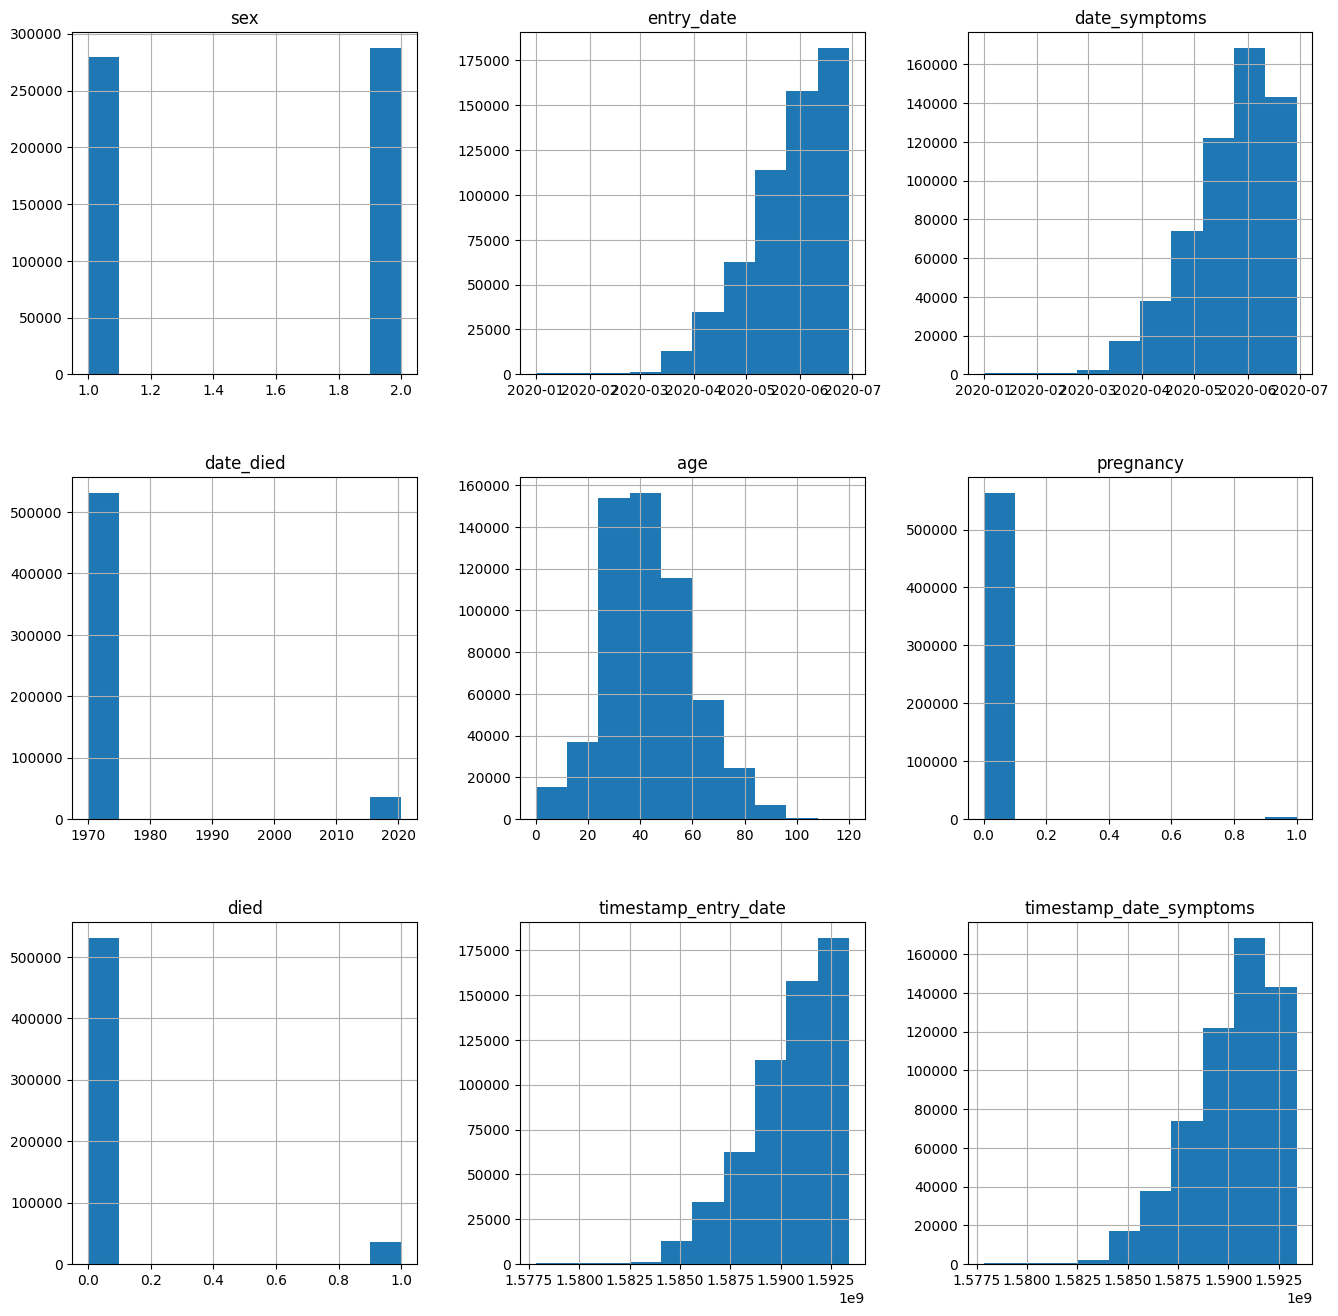

In [164]:
df.hist(figsize=(16,16),)
plt.show()


#### Box-plot

<Axes: >

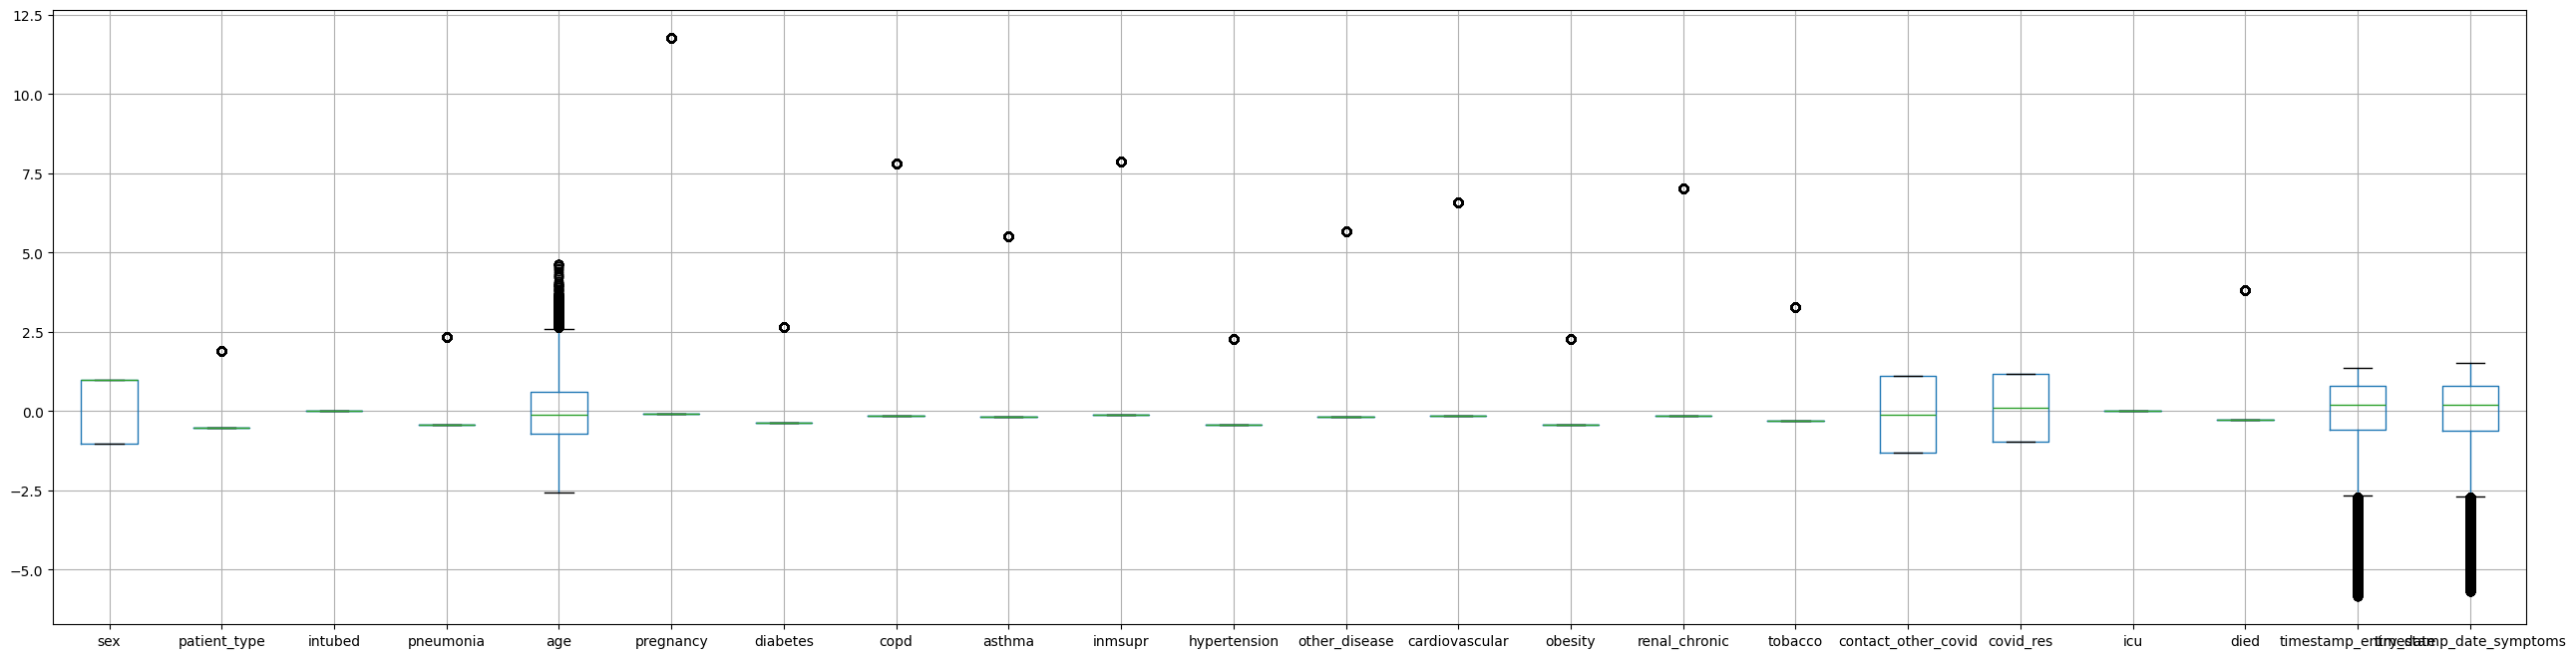

In [26]:
from sklearn.preprocessing import StandardScaler

scaled_df = df.select_dtypes(exclude=['datetime']).copy().astype(float)  

scaled_df[:] = StandardScaler().fit_transform(scaled_df)

scaled_df.boxplot(figsize=(32,8))


#### Male and female vs. *covid_res, age*

In [ ]:
male_covid_df =df[(df['sex']==2) & ( df['covid_res'] ==2)]
female_covid_df =df[df['sex']==1  & ( df['covid_res'] ==2)]

In [166]:
age_ml_mean = male_covid_df['age'].mean()
age_fl_mean = female_covid_df['age'].mean()

age_ml_median = male_covid_df['age'].median()
age_fl_median = female_covid_df['age'].median()

age_ml_max = male_covid_df['age'].max()
age_fl_max = female_covid_df['age'].max()

print(f"\u25CF Average age of male getting covid-19: {age_ml_mean.__round__(2)} years, The median:{age_ml_median}, Max:{age_ml_max}")
print(f"\u25CF Average age of female getting covid-19: {age_fl_mean.__round__(2)} years, The median:{age_fl_median}, Max:{age_fl_max}")

● Average age of male getting covid-19: 46.38 years, The median:45.0, Max:120
● Average age of female getting covid-19: 44.86 years, The median:44.0, Max:114


In [167]:
age_ml_std = male_covid_df['age'].std()
age_fl_std = female_covid_df['age'].std()

print(f"\u25CF Std of age of male getting covid-19: {age_ml_std.__round__(1)} years")
print(f"\u25CF Std of age of female getting covid-19: {age_fl_std.__round__(1)} years")

● Std of age of male getting covid-19: 16.3 years
● Std of age of female getting covid-19: 16.3 years


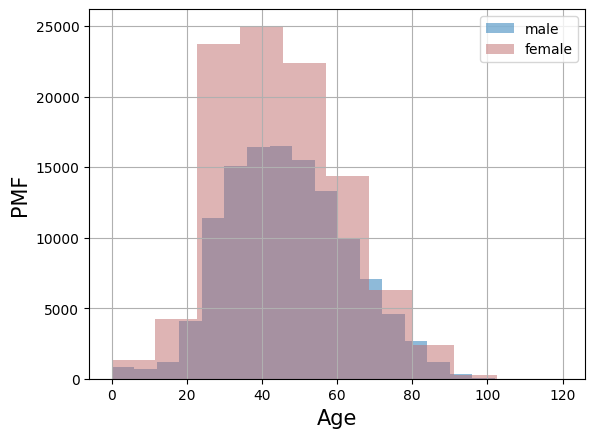

In [168]:
import seaborn as sns
male_covid_df['age'].hist(density=False, histtype='stepfilled', alpha=.5, bins=20)   # default number of bins = 10
female_covid_df['age'].hist(density=False, histtype='stepfilled', alpha=.5, color=sns.desaturate("indianred", .75), bins=10)
plt.xlabel('Age',fontsize=15)
plt.ylabel('PMF',fontsize=15)
plt.legend(["male",'female'])
plt.show()

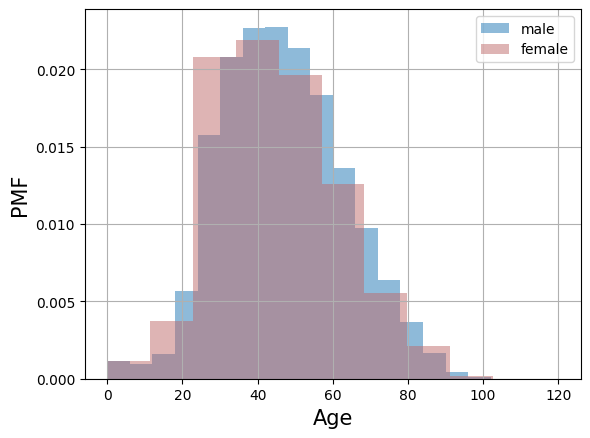

In [169]:
import seaborn as sns
male_covid_df['age'].hist(density=True, histtype='stepfilled', alpha=.5, bins=20)   # default number of bins = 10
female_covid_df['age'].hist(density=True, histtype='stepfilled', alpha=.5, color=sns.desaturate("indianred", .75), bins=10)
plt.xlabel('Age',fontsize=15)
plt.ylabel('PMF',fontsize=15)
plt.legend(["male",'female'])
plt.show()

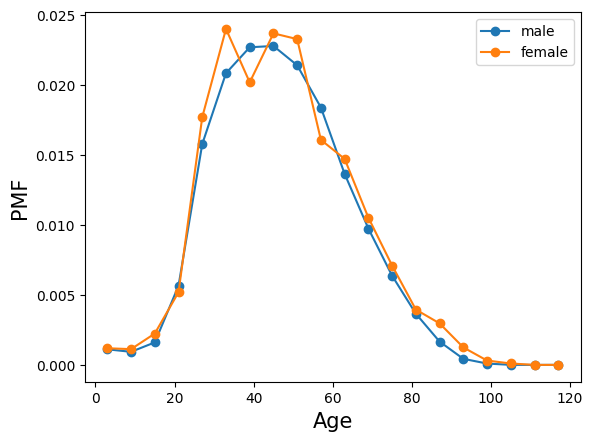

In [170]:
countx,divisionx = np.histogram(male_covid_df['age'], density=True,bins=20) 
county,divisiony = np.histogram(female_covid_df['age'], density=True,bins=20)

val = [(divisionx[i]+divisionx[i+1])/2 for i in range(len(divisionx)-1)]
plt.plot(val, countx, 'o-') 
plt.plot(val, county, 'o-') 
plt.legend(["male",'female'])
plt.xlabel('Age',fontsize=15)
plt.ylabel('PMF',fontsize=15)
plt.show()

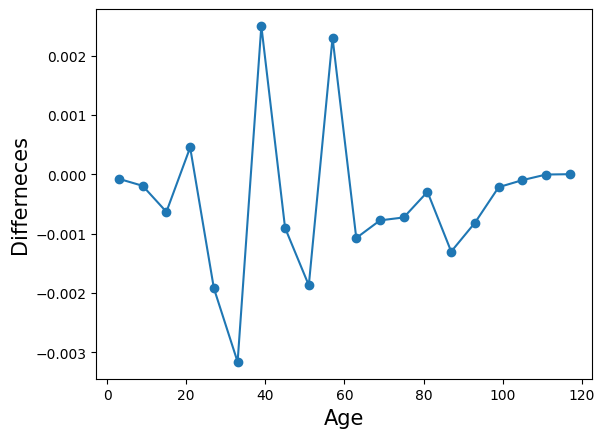

In [171]:
val = [(divisionx[i]+divisionx[i+1])/2 for i in range(len(divisionx)-1)]
plt.plot(val, countx-county, 'o-') 
plt.xlabel('Age',fontsize=15)
plt.ylabel('Differneces',fontsize=15)
plt.show()

+ In the 55 to 80 age group, male COVID‑19 cases occur at a higher percentage than female cases.
+ In contrast, in the 20 to 55 age group, female COVID‑19 cases are more prevalent than male cases.

In [172]:
ml2_age = male_covid_df['age']
print("Men grouped in 5 age categories:")
print("\u2022 Childhood (0–12):", int(round(100*len(ml2_age[ml2_age < 13]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Teen (13–17):", int(round(100*len(ml2_age[(ml2_age >= 13) & (ml2_age <= 17)]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Young Adult (18–39):", int(round(100*len(ml2_age[(ml2_age >= 18) & (ml2_age <= 39)]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Middle Age (40–64):", int(round(100*len(ml2_age[(ml2_age >= 40) & (ml2_age <= 64)]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Elderly (65+):", int(round(100*len(ml2_age[ml2_age >= 65]) / float(len(ml2_age.index)))), "%.")


Men grouped in 5 age categories:
• Childhood (0–12): 1 %.
• Teen (13–17): 1 %.
• Young Adult (18–39): 34 %.
• Middle Age (40–64): 49 %.
• Elderly (65+): 14 %.


In [173]:
ml2_age = female_covid_df['age']
print("Wemen grouped in 5 age categories:")

print("\u2022 Childhood (0–12):", int(round(100*len(ml2_age[ml2_age < 13]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Teen (13–17):", int(round(100*len(ml2_age[(ml2_age >= 13) & (ml2_age <= 17)]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Young Adult (18–39):", int(round(100*len(ml2_age[(ml2_age >= 18) & (ml2_age <= 39)]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Middle Age (40–64):", int(round(100*len(ml2_age[(ml2_age >= 40) & (ml2_age <= 64)]) / float(len(ml2_age.index)))), "%.")
print("\u2022 Elderly (65+):", int(round(100*len(ml2_age[ml2_age >= 65]) / float(len(ml2_age.index)))), "%.")


Wemen grouped in 5 age categories:
• Childhood (0–12): 1 %.
• Teen (13–17): 1 %.
• Young Adult (18–39): 38 %.
• Middle Age (40–64): 47 %.
• Elderly (65+): 13 %.


#### Sex vs. *diabetes, hypertension, obesity, died*

Test statistic (z)

$$
z = \frac{\hat{p}_1 - \hat{p}_2}
{\sqrt{\hat{p}\left(1 - \hat{p}\right)\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}
$$

In [174]:
import pandas as pd
import numpy as np
from scipy import stats

def two_proportion_diff_ci_ztest(x1, n1, x2, n2, alpha=0.05):
    """
    x1, n1: successes and total for group 1 (e.g., males)
    x2, n2: successes and total for group 2 (e.g., females)
    Returns: dict with proportions, difference, CI, z, p
    """
    x1 = float(x1)
    n1 = float(n1)
    x2 = float(x2)
    n2 = float(n2)

    p1 = x1 / n1
    p2 = x2 / n2
    diff = p1 - p2

    # Unpooled standard error for CI
    se_ci = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci_lower = diff - z_crit * se_ci
    ci_upper = diff + z_crit * se_ci

    # Pooled standard error for z-test
    p_pool = (x1 + x2) / (n1 + n2)
    se_z = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = diff / se_z
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))  # two-sided

    return {
        "p1": p1,
        "p2": p2,
        "diff": diff,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "z": z,
        "p_value": p_value,
        "x1": x1, "n1": n1,
        "x2": x2, "n2": n2
    }

def analyze_sex_vs_outcome(df, outcome_col, sex_col="sex"):
    """
    df: DataFrame
    outcome_col: name of binary outcome column (0/1)
    sex_col: column indicating sex, with values 1=female, 2=male
    """
    # Keep only rows with known sex (1 or 2)
    sub = df[df[sex_col].isin([1, 2])].copy()

    # Counts by sex
    counts = sub.groupby(sex_col)[outcome_col].agg(
        cases="sum",
        total="count"
    ).reset_index()

    # Extract rows for male (2) and female (1)
    male_row = counts.loc[counts[sex_col] == 2]
    female_row = counts.loc[counts[sex_col] == 1]

    if male_row.empty or female_row.empty:
        raise ValueError(f"Missing male or female rows for outcome '{outcome_col}'. "
                         f"Check sex coding and filtering.")

    # Get scalars, not Series
    x_m = male_row["cases"].iloc[0]
    n_m = male_row["total"].iloc[0]
    x_f = female_row["cases"].iloc[0]
    n_f = female_row["total"].iloc[0]

    res = two_proportion_diff_ci_ztest(x_m, n_m, x_f, n_f)

    out = {
        "outcome": outcome_col,
        "male_cases": int(x_m),
        "male_total": int(n_m),
        "male_prop": res["p1"],
        "female_cases": int(x_f),
        "female_total": int(n_f),
        "female_prop": res["p2"],
        "diff_male_minus_female": res["diff"],
        "ci_lower": res["ci_lower"],
        "ci_upper": res["ci_upper"],
        "z": res["z"],
        "p_value": res["p_value"]
    }
    return out


In [183]:
outcomes = ["diabetes", "hypertension", "obesity",'died']

results = []
for col in outcomes:
    res = analyze_sex_vs_outcome(df, col)
    results.append(res)

results_df = pd.DataFrame(results)
results_df.head()

,outcome,male_cases,male_total,male_prop,female_cases,female_total,female_prop,diff_male_minus_female,ci_lower,ci_upper,z,p_value
0,diabetes,37374,287112,0.130172,33457,279490,0.119707,0.010465,0.008743,0.012186,11.907747,0.000000e+00
1,hypertension,47781,287112,0.166419,44727,279490,0.160031,0.006389,0.004464,0.008313,6.504772,7.781109e-11
2,obesity,44754,287112,0.155876,47518,279490,0.170017,-0.014140,-0.016064,-0.012217,-14.412296,0.000000e+00
3,died,23480,287112,0.081780,12696,279490,0.045426,0.036354,0.035089,0.037620,55.960476,0.000000e+00


Reports
+ In this COVID‑19 dataset, men had a higher prevalence of diabetes than women.
 
+ Men also had a slightly higher prevalence of hypertension.
+ In contrast, obesity was more common in women than in men).
+ Finally, deaths were substantially more frequent among men than women, indicating a markedly higher mortality in men within  this cohort.

### Number entries analysis

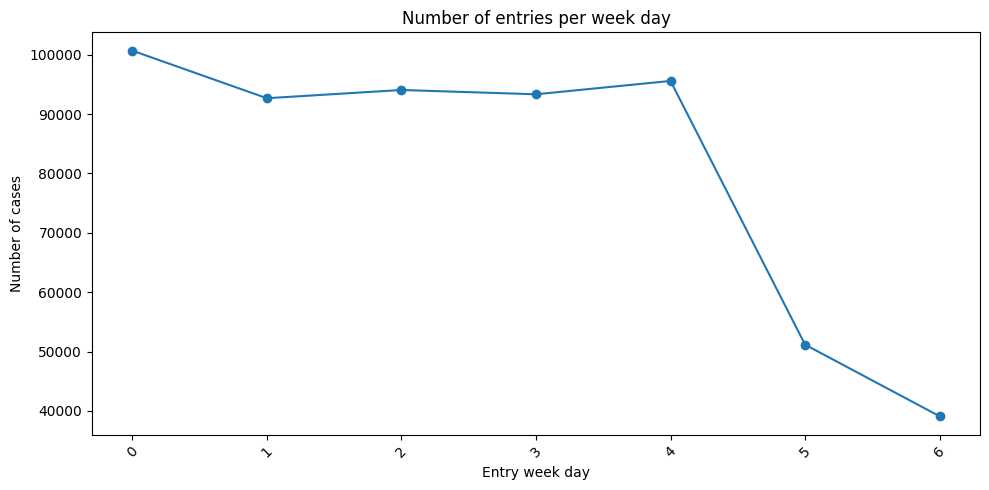

In [ ]:

# date_counts = df['entry_date'].value_counts().sort_index()
entries = df.groupby(df['entry_date'].dt.dayofweek).size()

plt.figure(figsize=(10, 5))
entries.plot(kind='line', marker='o',)
plt.xlabel('Entry week day')
plt.ylabel('Number of cases')
plt.title('Number of entries per week day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


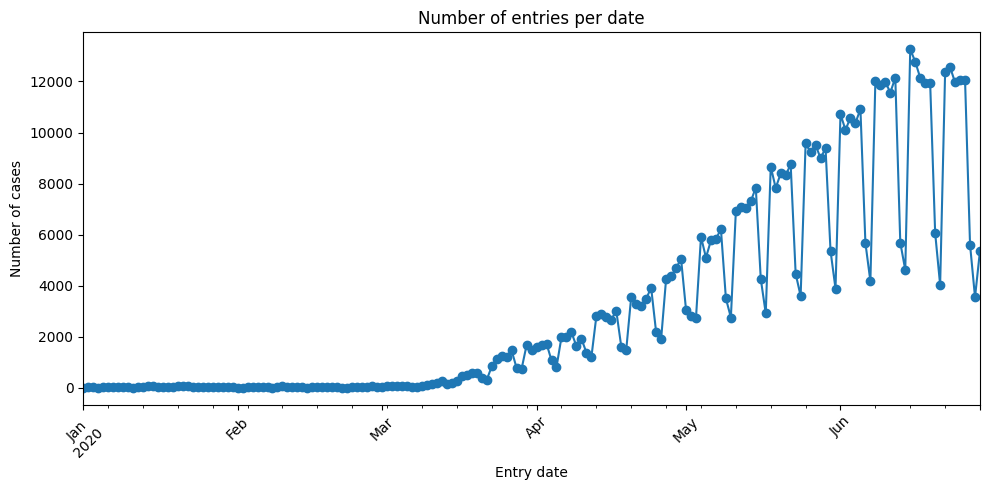

In [ ]:

# date_counts = df['entry_date'].value_counts().sort_index()
entries = df.groupby(['entry_date']).size()

plt.figure(figsize=(10, 5))
entries.plot(kind='line', marker='o')
plt.xlabel('Entry date')
plt.ylabel('Number of cases')
plt.title('Number of entries per date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


How many days passed after symptoms started before the patient was admitted, tested, or officially registered

In [ ]:
df['symptom_to_entry_days'] = (df['entry_date'] - df['date_symptoms']).dt.days
print(f"The average number of days between the onset of symptoms\n and the patient’s entry into the healthcare system is: {df['symptom_to_entry_days'].mean().__round__(0)} days")

The average number of days between the onset of symptoms
 and the patient’s entry into the healthcare system is: 4.0 days


In [ ]:
died_df = df[df['date_died']!='1970-01-01'].copy()
died_df['symptom_to_death_days'] = ( died_df['date_died'] - died_df['date_symptoms']).dt.days
died_df['entry_to_death_days'] = ( died_df['date_died'] - died_df['entry_date']).dt.days
print(f"\u25CF The average number of days between the onset of symptoms and the patient’s death is: {died_df['symptom_to_death_days'].mean().__round__(0)} days")
print(f"\u25CF The average number of days between the entry into the healthcare system and patient’s death is: {died_df['entry_to_death_days'].mean().__round__(0)} days")

● The average number of days between the onset of symptoms and the patient’s death is: 11.0 days
● The average number of days between the entry into the healthcare system and patient’s death is: 7.0 days


### Outliers


**Ouliers** are data samples with a value that is far from the central tendency.

We can find outliers by:

+ Computing samples that are *far* from the median.
+ Computing samples whose value *exceeds the mean* by 2 or 3 standard deviations.

This expression will return a series of boolean values that you can then index the series by:

In [ ]:
male_outliers = male_covid_df[abs(male_covid_df['age']-age_ml_mean)>3*age_ml_std]
print(f"Male outliers:{male_outliers.shape[0]}")

Male outliers:281


In [ ]:
female_outliers = female_covid_df[abs(female_covid_df['age']-age_fl_mean)>3*age_fl_std]
print(f"Female outliers:{female_outliers.shape[0]}")

Female outliers:682


Detecting outliers using the "mean ± 3 standard deviations" rule
- Among male patients, **281 observations** are classified as outliers.
- Among female patients, **682 observations** are classified as outliers.

This indicates that extreme values (relative to the mean) are present only in the male group under this criterion.


#### IQR method

In [ ]:
male_covid_df['age'].dtypes

dtype('int64')

In [ ]:
q1 = female_covid_df['age'].quantile(0.25)
q3 = female_covid_df['age'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = female_covid_df[
    (female_covid_df['age'] < lower) | 
    (female_covid_df['age'] > upper)
]
print(f"Female outliers:{outliers.shape[0]}")

Female outliers:2490


In [ ]:
q1 = male_covid_df['age'].quantile(0.25)
q3 = male_covid_df['age'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = male_covid_df[
    (male_covid_df['age'] < lower) | 
    (male_covid_df['age'] > upper)
]
print(f"Male outliers:{outliers.shape[0]}")

Male outliers:1269


Detecting outliers using the Median and Interquartile Range (IQR) method
- Among male patients, **2490 observations** are identified as outliers.
- Among female patients, **1269 observations** are identified as outliers.

This suggests that extreme age values occur only within the male group when applying the median‑based IQR criterion.
